In [1]:
import numpy as np
import gymnasium as gym
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import copy
from tqdm import tqdm

In this notebook, we will *naively* implement a neural network to approximate the Q function. Since value function approximation can handle large state spaces (even continuous). We use the *CartPole* environment with a continuous state space.

The core idea of Q learning with Q function approximation is to learn a Q function $\hat{q}(s,a,w)$ (*with optimal policy*) that approximates the true Q function. To achieve this, we use a neural network to approximate the Q function, and the function approximation problem turn into a optimization problem. We will use the mean squared error (MSE) as the loss function. The objective function is given by

\begin{equation}
J=\mathbb{E}\left[\left(R+\gamma \max _{a \in \mathcal{A}\left(S^{\prime}\right)} \hat{q}\left(S^{\prime}, a, w\right)-\hat{q}(S, A, w)\right)^2\right]
\end{equation}

Using gradient descent, we can update the weights of the neural network of Q function by

\begin{equation}
\nabla_w J=\mathbb{E}\left[\left(R+\gamma \max_{a \in \mathcal{A}\left(S^{\prime}\right)} \hat{q}\left(S^{\prime}, a, w\right)-\hat{q}(S, A, w)\right) \nabla_w \hat{q}(S, A, w)\right]
\end{equation}

\begin{equation}
w \gets w - \alpha_t \left(r_{t+1}+\gamma \max_{a^{\prime} \in \mathcal{A}(s_{t+1})} \hat{q}\left(s_{t+1}, a^{\prime}, w\right)-\hat{q}(s_t, a_t, w)\right) \nabla_{w} \hat{q}(s_t, a_t, w)
\end{equation}

Thanks to the *autogradient* feature of **PyTorch**, we can easily implement the above progress (i.e., solving the optimization problem).

Finally, we update the policy using the learnt Q function. Note that the exploitation part in such $\varepsilon$-greedy policy can be act as the target policy.

\begin{equation}
\begin{aligned}
& \pi_{t+1}\left(a \mid s_t\right)=1-\frac{\varepsilon}{|\mathcal{A}(s)|}(|\mathcal{A}(s)|-1) \text { if } a=\arg \max _{a \in \mathcal{A}\left(s_t\right)} \hat{q}\left(s_t, a, w_{t+1}\right) \\
& \pi_{t+1}\left(a \mid s_t\right)=\frac{\varepsilon}{|\mathcal{A}(s)|} \text { otherwise }
\end{aligned}
\end{equation}


In [2]:
class QNN_Agent():
    """ Since the discrete actions have been redefined as {0,1} by env, we can simply represent the action by a number. """
    
    def __init__(self,
                 Q_func:torch.nn.Module,
                 action_dim:int,
                 optimizer:torch.optim.Optimizer,
                 epsilon:float = 0.1,
                 gamma:float = 0.9,
                 device:torch.device = torch.device("cpu")
                 ) -> None:
        self.device = device
        self.action_dim = action_dim
        
        self.Q_func = Q_func
        self.optimizer = optimizer
        
        self.epsilon = epsilon
        self.gamma = gamma

    def get_target_action(self,obs:np.ndarray) -> int:
        """The input of nn must be a tensor. 
            Here, the input data of the agent is numpy arrays, so we need to convert it to tensor first """
        obs = torch.tensor(obs,dtype=torch.float32).to(self.device)
        Q_list = self.Q_func(obs)
        
        """The output of nn is a tensor, so we need to convert it to numpy array and then to int type"""
        action = torch.argmax(Q_list).item()
        
        return action

    def get_behavior_action(self,obs:np.ndarray) -> int:
        if np.random.uniform(0,1) < self.epsilon:
            action = np.random.choice(self.action_dim)
        else:
            action = self.get_target_action(obs)
            
        return action
    
    def Q_star_approximation(self,
                             obs:np.ndarray,
                             action:int,
                             reward:float,
                             next_obs:np.ndarray,
                             done:bool) -> float:
        
        obs = torch.tensor(obs,dtype=torch.float32).to(self.device)
        next_obs = torch.tensor(next_obs,dtype=torch.float32).to(self.device)
        current_Q = self.Q_func(obs)[action]
        TD_target = reward + (1-float(done)) * self.gamma * self.Q_func(next_obs).max()
        loss = F.mse_loss(current_Q,TD_target)
        # Now, we directly use gradient descent to optimize the loss
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()
                

Here, we use a simple MLP with 2 hidden layers to approximate the Q function.

In [3]:
class Q_Network(torch.nn.Module):
    """You can define your own network structure here."""
    def __init__(self,obs_dim:int,action_dim:int,hidden_size:int=64) -> None:
        super(Q_Network,self).__init__()
        self.fc1 = torch.nn.Linear(obs_dim,hidden_size)
        self.fc2 = torch.nn.Linear(hidden_size,action_dim)
            
    def forward(self,x:torch.tensor) -> torch.tensor:
        x = self.fc1(x)
        x = F.relu(x)
        x = self.fc2(x)
        
        return x

In [4]:
class TrainManager():
    def __init__(self,
                 env:gym.Env,
                 episode_num:int = 1000,
                 eval_iters:int = 10,
                 lr:float = 1e-3,
                 gamma:float = 0.9,
                 epsilon:float = 0.1,
                 seed:int = 0, # To compare the performance of different algorithms, we need to fix the random seed
                 my_device:str = "cpu"
                 ) -> None:
        
        """Set seeds"""
        self.seed = seed
        np.random.seed(self.seed)
        torch.manual_seed(self.seed)       
        torch.backends.cudnn.deterministic = True
        
        self.episode_num = episode_num
        self.device = torch.device(my_device)
        
        self.train_env = env
        self.eval_env = copy.deepcopy(env)
        _ = self.train_env.reset(seed=self.seed)
        _ = self.eval_env.reset(seed=self.seed+1)
        obs_dim = gym.spaces.utils.flatdim(env.observation_space) 
        action_dim = env.action_space.n 
        Q_func = Q_Network(obs_dim,action_dim).to(self.device)
        optimizer = torch.optim.Adam(Q_func.parameters(),lr=lr)
        self.agent = QNN_Agent(Q_func = Q_func,
                               action_dim = action_dim,
                               optimizer = optimizer,
                               epsilon = epsilon,
                               gamma = gamma,
                               device = self.device)
        
        self.eval_iters = eval_iters
        self.eval_rewards = [] 
    
    def train_episode(self) -> float:
        obs,_ = self.train_env.reset()
        done = False 
        while not done:
            action = self.agent.get_behavior_action(obs) 
            next_obs, reward, terminated, truncated, _ = self.train_env.step(action) 
            done = terminated or truncated
            self.agent.Q_star_approximation(obs,action,reward,next_obs,done)
            obs = next_obs   
    
    def train(self) -> None:       
        with tqdm(total=self.episode_num, desc='Training') as pbar:
            for _ in range(self.episode_num):
                self.train_episode()
                avg_reward = self.eval()
                pbar.set_postfix({"Avg. Test Reward": (avg_reward)})
                pbar.update(1)
    
    def eval(self) -> float:
        temp_eval_rewards = []
        for _ in range(self.eval_iters):
            obs,_ = self.eval_env.reset()
            episode_reward = 0
            done = False
            while not done:
                action = self.agent.get_target_action(obs)
                next_obs, reward, terminated, truncated, _ = self.eval_env.step(action)
                done = terminated or truncated
                episode_reward += reward
                obs = next_obs
                pass
            temp_eval_rewards.append(episode_reward)
            pass
        self.eval_rewards.append(temp_eval_rewards)
        
        return np.mean(temp_eval_rewards) 

In [5]:
train_env = gym.make('CartPole-v0')
Manager = TrainManager(env = train_env,
                    episode_num = 2000,
                    eval_iters = 10,
                    lr = 1e-3,
                    gamma = 0.9,
                    epsilon = 0.1,
                    seed = 0,
                    my_device = "cpu" # Use "cuda:?" if you want to use cuda. !! CPU is more efficient for these simple tasks 
                    )
Manager.train()

/home/zhura/miniconda3/envs/torch/lib/python3.8/site-packages/gymnasium/envs/registration.py:513: DeprecationWarning: WARN: The environment CartPole-v0 is out of date. You should consider upgrading to version `v1`.
  logger.deprecation(
Training: 100%|██████████| 2000/2000 [08:25<00:00,  3.96it/s, Avg. Test Reward=200] 


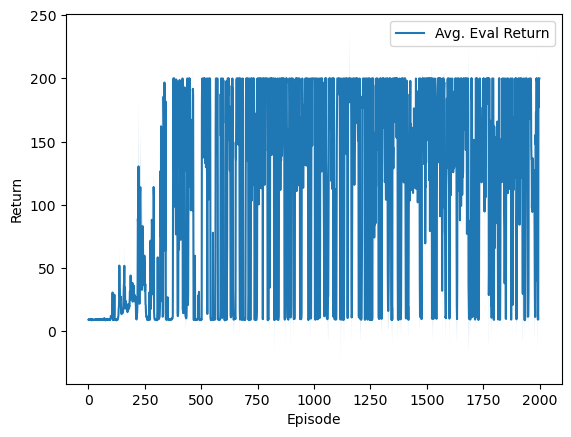

In [6]:
'''Plotting eval results'''
Manager.eval_rewards = np.array(Manager.eval_rewards)
means = np.mean(Manager.eval_rewards,axis=-1)
stds = np.std(Manager.eval_rewards,axis=-1)
plt.plot(means,label="Avg. Eval Return")
plt.fill_between(np.arange(len(means)),means-stds,means+stds,alpha=0.2)
plt.xlabel("Episode")
plt.ylabel("Return")
plt.legend()
plt.show()   